# Full-slide InstanSeg watershed scalability

This notebook tests whether the custom reconciliation can scale to a complete
slide using the patched InstanSeg checkout that preserves independently indexed
nuclei when native reconciliation is disabled.

Upstream inference is deliberately reused:

1. use the same explicit image, channels, and InstanSeg settings as the crop-scale watershed notebook;
2. resolve those channel names directly against the canonical full_merge OME-TIFF;
3. run forced medium-mode InstanSeg from the patched checkout with native reconciliation disabled;
4. export tiled uint32 unresolved nuclear and whole-cell TIFFs using pipeline helpers.

The scalability experiment begins from those unresolved TIFFs. They are reopened
lazily, copied once into disk-backed working arrays, reconciled in local object
windows, relabeled in row chunks, validated, and exported with the pipeline's
mask-writing settings.

The full-slide stages are explicit opt-ins so opening the notebook cannot
accidentally launch a large inference or overwrite experimental work.


## 1. Imports and runtime

In [1]:
from pathlib import Path
import gc, json, os, re, subprocess, sys, threading, time

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
from scipy import ndimage as ndi
from skimage.segmentation import watershed
import tifffile
import torch
import zarr

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = REPO_ROOT.parent
PATCHED_INSTANSEG_ROOT = (REPO_ROOT.parent / 'instanseg').resolve()
PATCHED_TILING = PATCHED_INSTANSEG_ROOT / 'instanseg/utils/tiling.py'
MODEL_CACHE = Path('/data1/lowes/ratnayn/conda_envs/instanseg_nimbus/lib/python3.10/site-packages/instanseg/bioimageio_models')
if not PATCHED_TILING.exists():
    raise FileNotFoundError(PATCHED_TILING)
if 'nuclei_map_list = map_list if labels_are_matched else None' not in PATCHED_TILING.read_text():
    raise RuntimeError('The selected InstanSeg checkout does not contain the nuclear stitching patch.')
loaded_instanseg = sys.modules.get('instanseg')
if loaded_instanseg is not None and PATCHED_INSTANSEG_ROOT not in Path(loaded_instanseg.__file__).resolve().parents:
    raise RuntimeError(f'InstanSeg is already loaded from {loaded_instanseg.__file__}. Restart the kernel.')
os.environ['INSTANSEG_BIOIMAGEIO_PATH'] = str(MODEL_CACHE)
sys.path.insert(0, str(PATCHED_INSTANSEG_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'src'))
PATCHED_INSTANSEG_HEAD = subprocess.run(
    ['git', '-C', str(PATCHED_INSTANSEG_ROOT), 'rev-parse', 'HEAD'],
    check=True, text=True, capture_output=True,
).stdout.strip()

from mif_pipeline.instanseg_runner import (
    _coerce_instances_array,
    _import_instanseg,
    _write_mask_tiffs,
)

try:
    import psutil
except ImportError:
    psutil = None

def format_duration(seconds):
    seconds = max(0.0, float(seconds))
    if seconds < 60:
        return f'{seconds:.1f}s'
    minutes, seconds = divmod(seconds, 60)
    if minutes < 60:
        return f'{int(minutes)}m {seconds:04.1f}s'
    hours, minutes = divmod(minutes, 60)
    return f'{int(hours)}h {int(minutes):02d}m {seconds:04.1f}s'

def stage_status(stage, started=None):
    if started is None:
        print(f'[{stage}] started', flush=True)
        return time.perf_counter()
    elapsed = time.perf_counter() - started
    timing_log.append({
        'stage': stage,
        'elapsed_seconds': elapsed,
        'elapsed': format_duration(elapsed),
        'status': 'completed',
    })
    print(f'[{stage}] finished in {format_duration(elapsed)}', flush=True)
    return elapsed

def progress_status(stage, completed, total, started, last_report):
    now = time.perf_counter()
    interval = globals().get('STATUS_EVERY_SECONDS', 30)
    if completed < total and now - last_report < interval:
        return last_report
    elapsed = max(now - started, 1e-9)
    fraction = completed / total if total else 1.0
    rate = completed / elapsed
    eta = (total - completed) / rate if rate > 0 else float('inf')
    eta_text = format_duration(eta) if np.isfinite(eta) else 'unknown'
    print(
        f'[{stage}] {completed:,}/{total:,} ({fraction:.1%}); '
        f'elapsed {format_duration(elapsed)}; ETA {eta_text}',
        flush=True,
    )
    return now

def timed_call(stage, function, *args, **kwargs):
    started = stage_status(stage)
    stop_event = threading.Event()

    def heartbeat():
        interval = globals().get('STATUS_EVERY_SECONDS', 30)
        while not stop_event.wait(interval):
            print(
                f'[{stage}] still running; elapsed '
                f'{format_duration(time.perf_counter() - started)}',
                flush=True,
            )

    thread = threading.Thread(target=heartbeat, daemon=True)
    thread.start()
    try:
        result = function(*args, **kwargs)
    except BaseException:
        failed_elapsed = time.perf_counter() - started
        timing_log.append({
            'stage': stage,
            'elapsed_seconds': failed_elapsed,
            'elapsed': format_duration(failed_elapsed),
            'status': 'failed',
        })
        print(
            f'[{stage}] failed after '
            f'{format_duration(failed_elapsed)}',
            flush=True,
        )
        raise
    finally:
        stop_event.set()
        thread.join(timeout=1)
    stage_status(stage, started)
    return result

def resource_snapshot(stage):
    row = {'stage': stage, 'time': time.time()}
    if psutil is not None:
        process = psutil.Process()
        row.update({
            'rss_gib': process.memory_info().rss / 2**30,
            'available_ram_gib': psutil.virtual_memory().available / 2**30,
        })
    if torch.cuda.is_available():
        row.update({
            'cuda_allocated_gib': torch.cuda.memory_allocated() / 2**30,
            'cuda_reserved_gib': torch.cuda.memory_reserved() / 2**30,
        })
    resource_log.append(row)
    print(row)
    return row

resource_log = []
timing_log = []
print(sys.executable)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('CUDA device:', torch.cuda.get_device_name(0))
print('repo:', REPO_ROOT)


/data1/lowes/ratnayn/conda_envs/instanseg_nimbus/bin/python
CUDA available: True
CUDA device: NVIDIA H200
repo: /data1/lowes/ratnayn/Codex/projects/mIF-pipeline


## 2. Full-slide inputs and watershed-notebook InstanSeg settings

This reuses the mIF-pipeline workflow and helper functions, not the settings from
a previous pipeline run. The editable values below match the current nucleus-proxy
watershed notebook. Channel indices are derived from the OME metadata, and native
nucleus/cell resolution remains disabled so the unresolved masks can be reconciled.
A dedicated patched-experiment directory and provenance sidecar prevent reuse of
pre-patch unresolved masks or replacement of canonical masks.


In [2]:
SLIDE_ID = 'SLIDE-0330'
FULL_MERGE_OME = Path(
    '/data1/lowes/ratnayn/Data/CellDive_analysis_data/image_data/'
    'SLIDE-0330/outputs_v3/SLIDE-0330_full_merge.ome.tif'
)
EXPERIMENT_TAG = 'patched_independent_nuclear_stitch'
OUTPUT_DIR = REPO_ROOT / 'experimental_data/instanseg_watershed_full_slide' / EXPERIMENT_TAG
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Explicit stage gates.
RUN_LOADER_DIAGNOSTIC = True
DIAGNOSTIC_FULL_PLANE = True  # Reads one complete channel; set False for metadata + crop only.
DIAGNOSTIC_CHANNEL_POSITION = 0
DIAGNOSTIC_CROP_SIZE = 4096
RUN_FULL_SLIDE_INFERENCE = True
RUN_WATERSHED_RECONCILIATION = True
RESUME_FINAL_RECONCILED = True  # Reopen completed work memmaps for validation/export.
WRITE_FINAL_TIFFS = True

FORCE_INFERENCE = True
REBUILD_WORK_MASKS = True
ROW_CHUNK = 512
STATUS_EVERY_SECONDS = 30

# USER-EDITABLE: copied from experimental_instanseg_watershed_nucleus_proxies.ipynb.
SEGMENTATION_CHANNELS = [
    'R1_DAPI',
    # 'R3_FITC_AF',
    'R4_P19_POLYRAT',
    'R4_GFP_POLY_AF488',
    'R6_CD45_CST_AF647',
    'R6_PANCK_AE1_AE3_750',
    'R12_CD31_D8V9E_AF750',
    'R7_NAK_ATPASE_555',
    # 'R8_PODOPLANIN_750',
    'R8_F480_D2S9R_555',
    'R9_CD68_E3O7V_488',
    'R12_CD3E_E4T1B_AF555',
]

MODEL_NAME = 'fluorescence_nuclei_and_cells'
PIXEL_SIZE_UM = 0.325
TILE_SIZE = 2000
BATCH_SIZE = 10
NUCLEI_PLANE = 0
CELLS_PLANE = 1

EVAL_KWARGS = {
    'normalise': True,
    'normalisation_subsampling_factor': 1,
    'rescale_output': True,
    'min_size': 10,
    'mask_threshold': 0.53,
    'peak_distance': 5,
    'seed_threshold': 0.7,
    'overlap_threshold': 0.3,
    'mean_threshold': 0.0,
    'fg_threshold': 0.5,
    'window_size': 32,
    'cleanup_fragments': True,
    'resolve_cell_and_nucleus': False,
}

# Same tiled uint32 export style as the mIF-pipeline, stated explicitly here.
MASK_EXPORT = {
    'bigtiff': True,
    'compression': 'zlib',
    'tile': [512, 512],
}

UNRESOLVED_SLIDE_ID = f'{SLIDE_ID}_unresolved'
UNRESOLVED_CELL_TIFF = OUTPUT_DIR / f'{UNRESOLVED_SLIDE_ID}_whole_cell.tiff'
UNRESOLVED_NUCLEAR_TIFF = OUTPUT_DIR / f'{UNRESOLVED_SLIDE_ID}_nuclear.tiff'
FINAL_CELL_TIFF = OUTPUT_DIR / f'{SLIDE_ID}_watershed_whole_cell.tiff'
FINAL_NUCLEAR_TIFF = OUTPUT_DIR / f'{SLIDE_ID}_watershed_nuclear.tiff'
WORK_CELL_DAT = OUTPUT_DIR / f'{SLIDE_ID}_watershed_work_cell.uint32.dat'
WORK_NUCLEAR_DAT = OUTPUT_DIR / f'{SLIDE_ID}_watershed_work_nuclear.uint32.dat'
WORK_STATE_JSON = OUTPUT_DIR / f'{SLIDE_ID}_watershed_work_state.json'
INFERENCE_PROVENANCE_JSON = OUTPUT_DIR / f'{SLIDE_ID}_unresolved_inference.json'

INFERENCE_PROVENANCE = {
    'instanseg_root': str(PATCHED_INSTANSEG_ROOT),
    'instanseg_head': PATCHED_INSTANSEG_HEAD,
    'nuclear_stitch_patch_present': True,
    'full_merge': str(FULL_MERGE_OME),
    'channels': SEGMENTATION_CHANNELS,
    'model': MODEL_NAME,
    'pixel_size_um': PIXEL_SIZE_UM,
    'tile_size': TILE_SIZE,
    'batch_size': BATCH_SIZE,
    'eval_kwargs': EVAL_KWARGS,
}

print('patched InstanSeg:', PATCHED_INSTANSEG_ROOT)
print('source HEAD:', PATCHED_INSTANSEG_HEAD)
print('experiment output:', OUTPUT_DIR)
print(f'Selected channels ({len(SEGMENTATION_CHANNELS)}):')
for channel_index, channel_name in enumerate(SEGMENTATION_CHANNELS):
    print(f'  {channel_index}: {channel_name}')


patched InstanSeg: /data1/lowes/ratnayn/Codex/projects/instanseg
source HEAD: 6bcde23d379a9bd3909652e93586d0db3b30c8a7
experiment output: /data1/lowes/ratnayn/Codex/projects/mIF-pipeline/experimental_data/instanseg_watershed_full_slide/patched_independent_nuclear_stitch
Selected channels (10):
  0: R1_DAPI
  1: R4_P19_POLYRAT
  2: R4_GFP_POLY_AF488
  3: R6_CD45_CST_AF647
  4: R6_PANCK_AE1_AE3_750
  5: R12_CD31_D8V9E_AF750
  6: R7_NAK_ATPASE_555
  7: R8_F480_D2S9R_555
  8: R9_CD68_E3O7V_488
  9: R12_CD3E_E4T1B_AF555


## 3. Metadata-only feasibility check

In [3]:
def channel_names_from_ome_xml(ome_xml):
    return re.findall(r'<Channel[^>]*Name="([^"]+)"', ome_xml or '')

metadata_started = stage_status('metadata feasibility check')
with tifffile.TiffFile(FULL_MERGE_OME) as handle:
    series = handle.series[0]
    source_shape = tuple(int(value) for value in series.shape)
    source_axes = series.axes
    source_dtype = np.dtype(series.dtype)
    source_names = channel_names_from_ome_xml(handle.ome_metadata)
    page = series.levels[0].pages[0]
    spatial_shape = tuple(int(value) for value in page.shape[-2:])
    source_tile = (int(page.tilelength), int(page.tilewidth))

missing_channels = [
    name for name in SEGMENTATION_CHANNELS if name not in source_names
]
assert not missing_channels, missing_channels
if len(SEGMENTATION_CHANNELS) != len(set(SEGMENTATION_CHANNELS)):
    raise ValueError(f'Duplicate segmentation channels: {SEGMENTATION_CHANNELS}')
channel_to_index = {name: index for index, name in enumerate(source_names)}
CHANNEL_INDICES = [channel_to_index[name] for name in SEGMENTATION_CHANNELS]
assert [source_names[index] for index in CHANNEL_INDICES] == SEGMENTATION_CHANNELS

height, width = spatial_shape
pixels = height * width
unresolved_mask_gib = 2 * pixels * np.dtype(np.uint32).itemsize / 2**30
working_mask_gib = unresolved_mask_gib
print({
    'source_shape': source_shape,
    'source_axes': source_axes,
    'source_dtype': str(source_dtype),
    'source_file_gib': FULL_MERGE_OME.stat().st_size / 2**30,
    'source_tile': source_tile,
    'selected_channels': len(SEGMENTATION_CHANNELS),
    'two_uint32_masks_gib': unresolved_mask_gib,
    'disk_backed_working_masks_gib': working_mask_gib,
})
plan = {
    'slide_id': SLIDE_ID,
    'experiment_tag': EXPERIMENT_TAG,
    'instanseg_root': str(PATCHED_INSTANSEG_ROOT),
    'instanseg_head': PATCHED_INSTANSEG_HEAD,
    'nuclear_stitch_patch_present': True,
    'full_merge': str(FULL_MERGE_OME),
    'channels': SEGMENTATION_CHANNELS,
    'channel_indices': CHANNEL_INDICES,
    'model': MODEL_NAME,
    'mode': 'medium',
    'pixel_size_um': PIXEL_SIZE_UM,
    'tile_size': TILE_SIZE,
    'batch_size': BATCH_SIZE,
    'eval_kwargs': EVAL_KWARGS,
    'mask_export': MASK_EXPORT,
    'unresolved_cell_tiff': str(UNRESOLVED_CELL_TIFF),
    'unresolved_nuclear_tiff': str(UNRESOLVED_NUCLEAR_TIFF),
    'final_cell_tiff': str(FINAL_CELL_TIFF),
    'final_nuclear_tiff': str(FINAL_NUCLEAR_TIFF),
}
display(plan)
resource_snapshot('metadata plan')
stage_status('metadata feasibility check', metadata_started)


[metadata feasibility check] started
{'source_shape': (72, 55388, 62688), 'source_axes': 'CYX', 'source_dtype': 'uint16', 'source_file_gib': 262.84075716976076, 'source_tile': (512, 512), 'selected_channels': 10, 'two_uint32_masks_gib': 25.869629859924316, 'disk_backed_working_masks_gib': 25.869629859924316}


{'slide_id': 'SLIDE-0330',
 'experiment_tag': 'patched_independent_nuclear_stitch',
 'instanseg_root': '/data1/lowes/ratnayn/Codex/projects/instanseg',
 'instanseg_head': '6bcde23d379a9bd3909652e93586d0db3b30c8a7',
 'nuclear_stitch_patch_present': True,
 'full_merge': '/data1/lowes/ratnayn/Data/CellDive_analysis_data/image_data/SLIDE-0330/outputs_v3/SLIDE-0330_full_merge.ome.tif',
 'channels': ['R1_DAPI',
  'R4_P19_POLYRAT',
  'R4_GFP_POLY_AF488',
  'R6_CD45_CST_AF647',
  'R6_PANCK_AE1_AE3_750',
  'R12_CD31_D8V9E_AF750',
  'R7_NAK_ATPASE_555',
  'R8_F480_D2S9R_555',
  'R9_CD68_E3O7V_488',
  'R12_CD3E_E4T1B_AF555'],
 'channel_indices': [4, 38, 42, 51, 52, 17, 56, 62, 71, 15],
 'model': 'fluorescence_nuclei_and_cells',
 'mode': 'medium',
 'pixel_size_um': 0.325,
 'tile_size': 2000,
 'batch_size': 10,
 'eval_kwargs': {'normalise': True,
  'normalisation_subsampling_factor': 1,
  'rescale_output': True,
  'min_size': 10,
  'mask_threshold': 0.53,
  'peak_distance': 5,
  'seed_threshold': 0

{'stage': 'metadata plan', 'time': 1787670763.7320561, 'rss_gib': 0.7794837951660156, 'available_ram_gib': 1920.6895446777344, 'cuda_allocated_gib': 0.0, 'cuda_reserved_gib': 0.0}
[metadata feasibility check] finished in 0.4s


0.3629139419645071

## 4. Diagnose selected-channel loading

Run this before full-slide inference. It reports the compressed and uncompressed
size of every selected channel, times a 4096-pixel tiled crop, and optionally
times one complete channel using the same `TiffPage.asarray()` call as the
production loader. The real loader below is also instrumented per channel.
No inference or output-mask writing occurs in this section.

In [4]:
def selected_channel_io_table(path, channel_indices, channel_names):
    rows = []
    with tifffile.TiffFile(path) as handle:
        pages = handle.series[0].levels[0].pages
        for name, index in zip(channel_names, channel_indices):
            page = pages[index]
            layout = page.keyframe
            raw_bytes = int(np.prod(page.shape, dtype=np.int64)) * np.dtype(page.dtype).itemsize
            compressed_bytes = int(sum(page.databytecounts))
            rows.append({
                'name': name, 'page_index': index, 'dtype': str(page.dtype),
                'shape': tuple(int(value) for value in page.shape),
                'compression': page.compression.name,
                'tile': (int(layout.tilelength), int(layout.tilewidth)),
                'tiles': len(page.dataoffsets),
                'raw_gib': raw_bytes / 2**30,
                'compressed_gib': compressed_bytes / 2**30,
                'compression_ratio': raw_bytes / compressed_bytes,
            })
    return pd.DataFrame(rows)

def benchmark_tiled_crop(path, channel_index, crop_size):
    started = time.perf_counter()
    with tifffile.TiffFile(path) as handle:
        store = handle.series[0].levels[0].aszarr()
        try:
            source = zarr.open(store, mode='r')
            if not hasattr(source, 'shape'):
                source = source['0']
            crop = np.asarray(source[channel_index, :crop_size, :crop_size])
        finally:
            store.close()
    elapsed = time.perf_counter() - started
    result = {
        'operation': f'zarr crop {crop_size}x{crop_size}',
        'channel_index': int(channel_index),
        'elapsed_seconds': elapsed,
        'output_gib': crop.nbytes / 2**30,
        'output_gib_per_second': crop.nbytes / 2**30 / max(elapsed, 1e-9),
    }
    del crop
    return result

def benchmark_full_page(path, channel_index):
    started = time.perf_counter()
    with tifffile.TiffFile(path) as handle:
        page = handle.series[0].levels[0].pages[channel_index]
        array = page.asarray()  # Exact read call used by the production helper.
    elapsed = time.perf_counter() - started
    result = {
        'operation': 'TiffPage.asarray full plane',
        'channel_index': int(channel_index),
        'elapsed_seconds': elapsed,
        'output_gib': array.nbytes / 2**30,
        'output_gib_per_second': array.nbytes / 2**30 / max(elapsed, 1e-9),
    }
    del array
    gc.collect()
    return result

def read_selected_channels_timed(path, channel_indices, channel_names):
    total_started = time.perf_counter()
    rows, arrays = [], []
    with tifffile.TiffFile(path) as handle:
        pages = handle.series[0].levels[0].pages
        for position, (name, index) in enumerate(zip(channel_names, channel_indices), start=1):
            started = time.perf_counter()
            print(f'[loader] channel {position}/{len(channel_indices)} started: {name} (page {index})', flush=True)
            array = pages[index].asarray()
            if array.ndim == 3 and array.shape[0] == 1:
                array = array[0]
            if array.ndim != 2:
                raise ValueError(f'Expected 2D channel plane, got {array.shape}')
            elapsed = time.perf_counter() - started
            arrays.append(array)
            rows.append({
                'stage': 'page read', 'channel': name, 'page_index': index,
                'elapsed_seconds': elapsed, 'gib': array.nbytes / 2**30,
                'gib_per_second': array.nbytes / 2**30 / max(elapsed, 1e-9),
            })
            print(f'[loader] channel {position}/{len(channel_indices)} finished in {format_duration(elapsed)}', flush=True)
            resource_snapshot(f'loaded channel {position}/{len(channel_indices)} {name}')
        pixel_size_match = re.search(r'PhysicalSizeX="([^"]+)"', handle.ome_metadata or '')
        pixel_size_um = float(pixel_size_match.group(1)) if pixel_size_match else None

    started = time.perf_counter()
    print('[loader] uint16 stack started', flush=True)
    stacked = np.stack(arrays, axis=0)
    del arrays
    del array
    elapsed = time.perf_counter() - started
    rows.append({'stage': 'uint16 stack', 'channel': 'all', 'page_index': None, 'elapsed_seconds': elapsed, 'gib': stacked.nbytes / 2**30, 'gib_per_second': stacked.nbytes / 2**30 / max(elapsed, 1e-9)})
    print(f'[loader] uint16 stack finished in {format_duration(elapsed)}', flush=True)
    resource_snapshot('after uint16 stack')

    started = time.perf_counter()
    print('[loader] float32 conversion started', flush=True)
    output = stacked.astype(np.float32, copy=False)
    del stacked
    elapsed = time.perf_counter() - started
    rows.append({'stage': 'float32 conversion', 'channel': 'all', 'page_index': None, 'elapsed_seconds': elapsed, 'gib': output.nbytes / 2**30, 'gib_per_second': output.nbytes / 2**30 / max(elapsed, 1e-9)})
    print(f'[loader] float32 conversion finished in {format_duration(elapsed)}', flush=True)
    print(f'[loader] total finished in {format_duration(time.perf_counter() - total_started)}', flush=True)
    resource_snapshot('after float32 conversion')
    return output, pixel_size_um, pd.DataFrame(rows)

loader_diagnostic = selected_channel_io_table(FULL_MERGE_OME, CHANNEL_INDICES, SEGMENTATION_CHANNELS)
display(loader_diagnostic)
display(loader_diagnostic[['raw_gib', 'compressed_gib']].sum().rename('selected_channel_totals'))

if RUN_LOADER_DIAGNOSTIC:
    diagnostic_position = int(DIAGNOSTIC_CHANNEL_POSITION)
    diagnostic_index = CHANNEL_INDICES[diagnostic_position]
    diagnostic_name = SEGMENTATION_CHANNELS[diagnostic_position]
    print(f'[diagnostic] selected {diagnostic_name} (page {diagnostic_index})', flush=True)
    diagnostic_rows = [benchmark_tiled_crop(FULL_MERGE_OME, diagnostic_index, DIAGNOSTIC_CROP_SIZE)]
    if DIAGNOSTIC_FULL_PLANE:
        diagnostic_rows.append(benchmark_full_page(FULL_MERGE_OME, diagnostic_index))
    loader_benchmark = pd.DataFrame(diagnostic_rows)
    display(loader_benchmark)
    resource_snapshot('after loader diagnostic')
else:
    print('Loader timing skipped; metadata table only.')

,name,page_index,dtype,shape,compression,tile,tiles,raw_gib,compressed_gib,compression_ratio
0,R1_DAPI,4,uint16,"(55388, 62688)",ADOBE_DEFLATE,"(512, 512)",13407,6.467407,3.358721,1.925557
1,R4_P19_POLYRAT,38,uint16,"(55388, 62688)",ADOBE_DEFLATE,"(512, 512)",13407,6.467407,3.165748,2.042932
2,R4_GFP_POLY_AF488,42,uint16,"(55388, 62688)",ADOBE_DEFLATE,"(512, 512)",13407,6.467407,3.691241,1.752096
3,R6_CD45_CST_AF647,51,uint16,"(55388, 62688)",ADOBE_DEFLATE,"(512, 512)",13407,6.467407,1.070239,6.042958
4,R6_PANCK_AE1_AE3_750,52,uint16,"(55388, 62688)",ADOBE_DEFLATE,"(512, 512)",13407,6.467407,1.368488,4.725950
5,R12_CD31_D8V9E_AF750,17,uint16,"(55388, 62688)",ADOBE_DEFLATE,"(512, 512)",13407,6.467407,2.261144,2.860237
6,R7_NAK_ATPASE_555,56,uint16,"(55388, 62688)",ADOBE_DEFLATE,"(512, 512)",13407,6.467407,3.092769,2.091138
7,R8_F480_D2S9R_555,62,uint16,"(55388, 62688)",ADOBE_DEFLATE,"(512, 512)",13407,6.467407,2.983229,2.167922
8,R9_CD68_E3O7V_488,71,uint16,"(55388, 62688)",ADOBE_DEFLATE,"(512, 512)",13407,6.467407,2.822802,2.291131
9,R12_CD3E_E4T1B_AF555,15,uint16,"(55388, 62688)",ADOBE_DEFLATE,"(512, 512)",13407,6.467407,2.996297,2.158467


raw_gib           64.674075
compressed_gib    26.810677
Name: selected_channel_totals, dtype: float64

[diagnostic] selected R1_DAPI (page 4)


,operation,channel_index,elapsed_seconds,output_gib,output_gib_per_second
0,zarr crop 4096x4096,4,0.227671,0.031250,0.137260
1,TiffPage.asarray full plane,4,4.353893,6.467407,1.485431


{'stage': 'after loader diagnostic', 'time': 1787670769.3023515, 'rss_gib': 1.1727218627929688, 'available_ram_gib': 1919.8791275024414, 'cuda_allocated_gib': 0.0, 'cuda_reserved_gib': 0.0}


## 5. Run one full-slide unresolved medium-mode inference

This follows the normal pipeline call pattern while explicitly importing the
patched checkout. The helper reads only the selected
full-merge channel planes, eval_medium_image performs tiled inference and
stitching, and the pipeline writer exports full-resolution tiled uint32 masks.

Set RUN_FULL_SLIDE_INFERENCE=True to run. Existing experimental outputs are
reused unless FORCE_INFERENCE=True.


In [5]:
if RUN_FULL_SLIDE_INFERENCE:
    full_inference_started = stage_status('full-slide unresolved inference stage')
    outputs_exist = UNRESOLVED_CELL_TIFF.exists() and UNRESOLVED_NUCLEAR_TIFF.exists()
    if outputs_exist and not FORCE_INFERENCE:
        if not INFERENCE_PROVENANCE_JSON.exists():
            raise RuntimeError(
                'Unresolved masks exist without patched-source provenance. '
                'Set FORCE_INFERENCE=True to replace them.'
            )
        observed_provenance = json.loads(INFERENCE_PROVENANCE_JSON.read_text())
        if observed_provenance != INFERENCE_PROVENANCE:
            raise RuntimeError(
                'Existing unresolved masks were created with different source or settings. '
                'Set FORCE_INFERENCE=True to replace them.'
            )
        print('[inference] reusing existing unresolved masks', flush=True)
        print('  cell:', UNRESOLVED_CELL_TIFF, flush=True)
        print('  nuclei:', UNRESOLVED_NUCLEAR_TIFF, flush=True)
    else:
        resource_snapshot('before selected-channel load')
        image_array, pixel_size_read, selected_channel_timing = timed_call(
            'selected-channel OME-TIFF load',
            read_selected_channels_timed,
            FULL_MERGE_OME,
            CHANNEL_INDICES,
            SEGMENTATION_CHANNELS,
        )
        display(selected_channel_timing)
        resource_snapshot('after selected-channel load')
        print(
            f'[selected-channel OME-TIFF load] array={image_array.shape}, '
            f'dtype={image_array.dtype}',
            flush=True,
        )

        InstanSeg = _import_instanseg()
        import instanseg
        imported_source = Path(instanseg.__file__).resolve()
        if PATCHED_INSTANSEG_ROOT not in imported_source.parents:
            raise RuntimeError(f'Expected patched InstanSeg, imported {imported_source}')
        print('[inference] InstanSeg source:', imported_source, flush=True)
        inst = timed_call(
            'InstanSeg model initialization', InstanSeg, MODEL_NAME, verbosity=1
        )
        instances = timed_call(
            'InstanSeg medium inference',
            inst.eval_medium_image,
            image_array,
            pixel_size=PIXEL_SIZE_UM if PIXEL_SIZE_UM is not None else pixel_size_read,
            tile_size=TILE_SIZE,
            batch_size=BATCH_SIZE,
            return_image_tensor=False,
            **EVAL_KWARGS,
        )
        del image_array
        gc.collect()
        resource_snapshot('after unresolved medium inference')

        instances_array = _coerce_instances_array(instances)
        del instances
        experimental_slide = {
            'slide_id': UNRESOLVED_SLIDE_ID,
            'mask_export': {
                'mask_dir': str(OUTPUT_DIR),
                'suffix': '_whole_cell.tiff',
                'nuclear_suffix': '_nuclear.tiff',
                'bigtiff': MASK_EXPORT['bigtiff'],
                'compression': MASK_EXPORT['compression'],
                'tile': list(MASK_EXPORT['tile']),
            },
        }
        write_result = timed_call(
            'unresolved mask TIFF export',
            _write_mask_tiffs,
            experimental_slide,
            ome_path=FULL_MERGE_OME,
            instances_array=instances_array,
            nuclei_plane=NUCLEI_PLANE,
            cells_plane=CELLS_PLANE,
        )
        del instances_array
        gc.collect()
        INFERENCE_PROVENANCE_JSON.write_text(json.dumps(INFERENCE_PROVENANCE, indent=2))
        resource_snapshot('after unresolved mask export')
        display(write_result)
    stage_status('full-slide unresolved inference stage', full_inference_started)
else:
    print('Planning only. Set RUN_FULL_SLIDE_INFERENCE=True to create unresolved masks.')


[full-slide unresolved inference stage] started
{'stage': 'before selected-channel load', 'time': 1787670788.2964933, 'rss_gib': 1.1732063293457031, 'available_ram_gib': 1920.0564460754395, 'cuda_allocated_gib': 0.0, 'cuda_reserved_gib': 0.0}
[selected-channel OME-TIFF load] started
[loader] channel 1/10 started: R1_DAPI (page 4)
[loader] channel 1/10 finished in 3.7s
{'stage': 'loaded channel 1/10 R1_DAPI', 'time': 1787670792.1105015, 'rss_gib': 7.852436065673828, 'available_ram_gib': 1912.7820625305176, 'cuda_allocated_gib': 0.0, 'cuda_reserved_gib': 0.0}
[loader] channel 2/10 started: R4_P19_POLYRAT (page 38)
[loader] channel 2/10 finished in 3.9s
{'stage': 'loaded channel 2/10 R4_P19_POLYRAT', 'time': 1787670795.9708147, 'rss_gib': 14.320564270019531, 'available_ram_gib': 1907.0888137817383, 'cuda_allocated_gib': 0.0, 'cuda_reserved_gib': 0.0}
[loader] channel 3/10 started: R4_GFP_POLY_AF488 (page 42)
[loader] channel 3/10 finished in 4.3s
{'stage': 'loaded channel 3/10 R4_GFP_POLY

,stage,channel,page_index,elapsed_seconds,gib,gib_per_second
0,page read,R1_DAPI,4.0,3.727578,6.467407,1.735016
1,page read,R4_P19_POLYRAT,38.0,3.858273,6.467407,1.676244
2,page read,R4_GFP_POLY_AF488,42.0,4.268368,6.467407,1.515194
3,page read,R6_CD45_CST_AF647,51.0,2.175087,6.467407,2.973402
4,page read,R6_PANCK_AE1_AE3_750,52.0,2.403989,6.467407,2.690282
5,page read,R12_CD31_D8V9E_AF750,17.0,2.953668,6.467407,2.189619
6,page read,R7_NAK_ATPASE_555,56.0,3.136635,6.467407,2.061894
7,page read,R8_F480_D2S9R_555,62.0,3.883253,6.467407,1.665461
8,page read,R9_CD68_E3O7V_488,71.0,3.296513,6.467407,1.961893
9,page read,R12_CD3E_E4T1B_AF555,15.0,3.483554,6.467407,1.856554


{'stage': 'after selected-channel load', 'time': 1787671515.3148642, 'rss_gib': 130.68582153320312, 'available_ram_gib': 1791.7129859924316, 'cuda_allocated_gib': 0.0, 'cuda_reserved_gib': 0.0}
[selected-channel OME-TIFF load] array=(10, 55388, 62688), dtype=float32
[inference] InstanSeg source: /data1/lowes/ratnayn/Codex/projects/instanseg/instanseg/__init__.py
[InstanSeg model initialization] started
Model fluorescence_nuclei_and_cells version 0.1.1 already downloaded in /data1/lowes/ratnayn/conda_envs/instanseg_nimbus/lib/python3.10/site-packages/instanseg/bioimageio_models, loading
Requesting default device: cuda
[InstanSeg model initialization] finished in 0.6s
[InstanSeg medium inference] started
[InstanSeg medium inference] still running; elapsed 30.0s
[InstanSeg medium inference] still running; elapsed 1m 00.0s
[InstanSeg medium inference] still running; elapsed 1m 30.0s
[InstanSeg medium inference] still running; elapsed 2m 00.0s
[InstanSeg medium inference] still running; ela

  9%|▊         | 4/46 [00:13<02:16,  3.26s/it]

[InstanSeg medium inference] still running; elapsed 10m 00.0s


...

[InstanSeg medium inference] still running; elapsed 12m 00.0s


/data1/lowes/ratnayn/Codex/projects/instanseg/instanseg/utils/pytorch_utils.py:312: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  intersection = torch.sparse.mm(onehot1, onehot2.T).to_dense()


[InstanSeg medium inference] still running; elapsed 12m 30.0s
[InstanSeg medium inference] still running; elapsed 13m 00.0s
[InstanSeg medium inference] still running; elapsed 13m 30.0s
[InstanSeg medium inference] still running; elapsed 14m 00.0s
[InstanSeg medium inference] still running; elapsed 14m 30.0s
[InstanSeg medium inference] still running; elapsed 15m 00.0s
[InstanSeg medium inference] still running; elapsed 15m 30.0s
[InstanSeg medium inference] still running; elapsed 16m 00.0s
[InstanSeg medium inference] still running; elapsed 16m 30.0s
[InstanSeg medium inference] still running; elapsed 17m 00.0s
[InstanSeg medium inference] still running; elapsed 17m 30.0s
[InstanSeg medium inference] still running; elapsed 18m 00.0s
[InstanSeg medium inference] still running; elapsed 18m 30.1s
[InstanSeg medium inference] still running; elapsed 19m 00.1s
[InstanSeg medium inference] still running; elapsed 19m 30.1s
[InstanSeg medium inference] still running; elapsed 20m 00.1s
[InstanS

{'cell_mask_path': '/data1/lowes/ratnayn/Codex/projects/mIF-pipeline/experimental_data/instanseg_watershed_full_slide/patched_independent_nuclear_stitch/SLIDE-0330_unresolved_whole_cell.tiff',
 'nuclear_mask_path': '/data1/lowes/ratnayn/Codex/projects/mIF-pipeline/experimental_data/instanseg_watershed_full_slide/patched_independent_nuclear_stitch/SLIDE-0330_unresolved_nuclear.tiff',
 'target_shape': [55388, 62688],
 'cell_mask_shape': [55388, 62688],
 'nuclear_mask_shape': [55388, 62688],
 'mask_dtype': 'uint32'}

[full-slide unresolved inference stage] finished in 1h 01m 19.9s


## 6. Open unresolved TIFFs lazily and prepare disk-backed working masks

The compressed tiled TIFFs remain the restartable unresolved artifacts. Writable
uint32 memmaps are a temporary reconciliation workspace; only ROW_CHUNK rows are
materialized while copying or relabeling. With `RESUME_FINAL_RECONCILED=True`,
this section verifies provenance and opens an existing final state read-only;
association, watershed, and relabeling sections are then skipped.


In [6]:
def open_tiff_as_zarr(path):
    store = tifffile.imread(str(path), aszarr=True)
    array = zarr.open(store, mode='r')
    return store, array

def copy_lazy_mask_to_memmap(source, destination, shape, row_chunk, label):
    started = stage_status(f'copy {label} to working memmap')
    last_report = started
    target = np.memmap(destination, mode='w+', dtype=np.uint32, shape=shape)
    maximum = 0
    for y0 in range(0, shape[0], row_chunk):
        y1 = min(shape[0], y0 + row_chunk)
        block = np.asarray(source[y0:y1], dtype=np.uint32)
        target[y0:y1] = block
        maximum = max(maximum, int(block.max(initial=0)))
        last_report = progress_status(
            f'copy {label}', y1, shape[0], started, last_report
        )
    timed_call(f'flush {label} working memmap', target.flush)
    stage_status(f'copy {label} to working memmap', started)
    return target, maximum

if not (UNRESOLVED_CELL_TIFF.exists() and UNRESOLVED_NUCLEAR_TIFF.exists()):
    raise FileNotFoundError(
        'Unresolved masks do not exist. Run section 4 or point the paths at '
        'existing resolve_cell_and_nucleus=False full-slide masks.'
    )

open_started = stage_status('open unresolved TIFFs lazily')
cell_store, lazy_raw_cells = open_tiff_as_zarr(UNRESOLVED_CELL_TIFF)
nuclear_store, lazy_raw_nuclei = open_tiff_as_zarr(UNRESOLVED_NUCLEAR_TIFF)
stage_status('open unresolved TIFFs lazily', open_started)
assert lazy_raw_cells.shape == lazy_raw_nuclei.shape == spatial_shape
assert np.dtype(lazy_raw_cells.dtype) == np.uint32
assert np.dtype(lazy_raw_nuclei.dtype) == np.uint32
print('lazy cell:', lazy_raw_cells)
print('lazy nuclei:', lazy_raw_nuclei)

if RESUME_FINAL_RECONCILED:
    resume_started = stage_status('resume final reconciled working memmaps')
    if not WORK_STATE_JSON.exists():
        raise FileNotFoundError(WORK_STATE_JSON)
    state = json.loads(WORK_STATE_JSON.read_text())
    if state.get('state') != 'final_reconciled':
        raise RuntimeError(f"Cannot resume state {state.get('state')!r}; expected 'final_reconciled'.")
    if state.get('inference_provenance') != INFERENCE_PROVENANCE:
        raise RuntimeError('Final working masks do not match the patched inference source/settings.')
    if tuple(state.get('shape', ())) != tuple(spatial_shape):
        raise RuntimeError(f"Final working-mask shape mismatch: {state.get('shape')} != {spatial_shape}")
    max_raw_cell_id = int(state['max_raw_cell_id'])
    max_raw_nucleus_id = int(state['max_raw_nucleus_id'])
    next_cell_id = int(state['max_final_cell_id']) + 1
    proxy_start_id = int(state['proxy_start_id'])
    proxy_stop_id = int(state['proxy_stop_id'])
    association_summary = dict(state.get('association_summary', {}))
    watershed_qc = pd.DataFrame()  # Per-split records were in memory only.
    final_cells = np.memmap(WORK_CELL_DAT, mode='r', dtype=np.uint32, shape=spatial_shape)
    final_nuclei = np.memmap(WORK_NUCLEAR_DAT, mode='r', dtype=np.uint32, shape=spatial_shape)
    print('resumed:', WORK_STATE_JSON)
    display(association_summary)
    stage_status('resume final reconciled working memmaps', resume_started)
elif REBUILD_WORK_MASKS or not (WORK_CELL_DAT.exists() and WORK_NUCLEAR_DAT.exists()):
    resource_snapshot('before work-mask copy')
    final_cells, max_raw_cell_id = copy_lazy_mask_to_memmap(
        lazy_raw_cells, WORK_CELL_DAT, spatial_shape, ROW_CHUNK, 'cell mask'
    )
    final_nuclei, max_raw_nucleus_id = copy_lazy_mask_to_memmap(
        lazy_raw_nuclei, WORK_NUCLEAR_DAT, spatial_shape, ROW_CHUNK, 'nuclear mask'
    )
    WORK_STATE_JSON.write_text(json.dumps({
        'state': 'raw_unresolved',
        'cell_source': str(UNRESOLVED_CELL_TIFF),
        'nuclear_source': str(UNRESOLVED_NUCLEAR_TIFF),
        'inference_provenance': INFERENCE_PROVENANCE,
        'shape': list(spatial_shape),
        'max_raw_cell_id': max_raw_cell_id,
        'max_raw_nucleus_id': max_raw_nucleus_id,
    }, indent=2))
    resource_snapshot('after work-mask copy')
else:
    reuse_started = stage_status('open existing working memmaps')
    state = json.loads(WORK_STATE_JSON.read_text())
    if state.get('state') != 'raw_unresolved':
        raise RuntimeError(
            f'Working masks are in state {state.get("state")!r}. '
            'Set REBUILD_WORK_MASKS=True before rerunning reconciliation.'
        )
    if state.get('inference_provenance') != INFERENCE_PROVENANCE:
        raise RuntimeError(
            'Working masks do not match the patched inference source/settings. '
            'Set REBUILD_WORK_MASKS=True.'
        )
    max_raw_cell_id = int(state['max_raw_cell_id'])
    max_raw_nucleus_id = int(state['max_raw_nucleus_id'])
    final_cells = np.memmap(
        WORK_CELL_DAT, mode='r+', dtype=np.uint32, shape=spatial_shape
    )
    final_nuclei = np.memmap(
        WORK_NUCLEAR_DAT, mode='r+', dtype=np.uint32, shape=spatial_shape
    )
    stage_status('open existing working memmaps', reuse_started)


[open unresolved TIFFs lazily] started
[open unresolved TIFFs lazily] finished in 0.0s
lazy cell: <zarr.core.Array (55388, 62688) uint32 read-only>
lazy nuclei: <zarr.core.Array (55388, 62688) uint32 read-only>
[resume final reconciled working memmaps] started
resumed: /data1/lowes/ratnayn/Codex/projects/mIF-pipeline/experimental_data/instanseg_watershed_full_slide/patched_independent_nuclear_stitch/SLIDE-0330_watershed_work_state.json


{'raw_cells': 1615625,
 'raw_nuclei': 1606936,
 'single_nucleus_cells': 1398003,
 'ambiguous_cells': 55338,
 'unmatched_nuclei': 97133,
 'overlap_count_seconds': 48.94083613483235}

[resume final reconciled working memmaps] finished in 0.0s


## 7. Count overlap pairs in row chunks

This replaces crop-scale full-image Boolean masks and pair arrays. Per-chunk
unique pair counts are reduced into the same strict greater-than-50% nucleus
overlap rule used by the inspection notebook.


In [7]:
def reduce_code_counts(code_parts, count_parts):
    if not code_parts:
        return np.array([], dtype=np.uint64), np.array([], dtype=np.int64)
    codes = np.concatenate(code_parts)
    counts = np.concatenate(count_parts)
    order = np.argsort(codes)
    codes = codes[order]
    counts = counts[order]
    starts = np.r_[0, np.flatnonzero(codes[1:] != codes[:-1]) + 1]
    return codes[starts], np.add.reduceat(counts, starts)

def compute_overlap_counts_chunked(cell_labels, nucleus_labels, row_chunk):
    started = stage_status('chunked cell/nucleus overlap scan')
    last_report = started
    max_cell = int(max_raw_cell_id)
    max_nucleus = int(max_raw_nucleus_id)
    cell_areas = np.zeros(max_cell + 1, dtype=np.int64)
    nucleus_areas = np.zeros(max_nucleus + 1, dtype=np.int64)
    pair_base = np.uint64(max_nucleus + 1)
    code_parts, count_parts = [], []

    for y0 in range(0, cell_labels.shape[0], row_chunk):
        y1 = min(cell_labels.shape[0], y0 + row_chunk)
        cells = np.asarray(cell_labels[y0:y1])
        nuclei = np.asarray(nucleus_labels[y0:y1])
        cell_areas += np.bincount(cells.ravel(), minlength=max_cell + 1)
        nucleus_areas += np.bincount(nuclei.ravel(), minlength=max_nucleus + 1)

        both = (cells > 0) & (nuclei > 0)
        if np.any(both):
            codes = (
                cells[both].astype(np.uint64) * pair_base
                + nuclei[both].astype(np.uint64)
            )
            unique_codes, counts = np.unique(codes, return_counts=True)
            code_parts.append(unique_codes)
            count_parts.append(counts.astype(np.int64, copy=False))
        last_report = progress_status(
            'overlap scan rows', y1, cell_labels.shape[0], started, last_report
        )

    stage_status('chunked cell/nucleus overlap scan', started)
    pair_codes, pair_counts = timed_call(
        'reduce overlap-pair counts', reduce_code_counts, code_parts, count_parts
    )
    pair_cell_ids = (pair_codes // pair_base).astype(np.uint32)
    pair_nucleus_ids = (pair_codes % pair_base).astype(np.uint32)
    return cell_areas, nucleus_areas, pair_cell_ids, pair_nucleus_ids, pair_counts

if RUN_WATERSHED_RECONCILIATION and not RESUME_FINAL_RECONCILED:
    overlap_stage_started = stage_status('association analysis')
    resource_snapshot('before chunked overlap count')
    (
        raw_cell_areas,
        raw_nucleus_areas,
        pair_cell_ids,
        pair_nucleus_ids,
        pair_overlap_pixels,
    ) = compute_overlap_counts_chunked(final_cells, final_nuclei, ROW_CHUNK)

    pair_overlap_fraction = (
        pair_overlap_pixels / raw_nucleus_areas[pair_nucleus_ids]
    )
    qualifies = pair_overlap_fraction > 0.5
    qualifying_cell_ids = pair_cell_ids[qualifies]
    qualifying_nucleus_ids = pair_nucleus_ids[qualifies]

    qualifying_by_cell = {}
    for cell_id, nucleus_id in zip(
        qualifying_cell_ids.astype(int),
        qualifying_nucleus_ids.astype(int),
    ):
        qualifying_by_cell.setdefault(cell_id, []).append(nucleus_id)

    raw_cell_ids = np.flatnonzero(raw_cell_areas[1:]) + 1
    raw_nucleus_ids = np.flatnonzero(raw_nucleus_areas[1:]) + 1
    matched_nucleus = np.zeros(max_raw_nucleus_id + 1, dtype=bool)
    matched_nucleus[qualifying_nucleus_ids] = True
    unmatched_nucleus_ids = raw_nucleus_ids[~matched_nucleus[raw_nucleus_ids]]
    ambiguous_cell_ids = np.array([
        cell_id for cell_id, nuclei in qualifying_by_cell.items()
        if len(nuclei) > 1
    ], dtype=np.int64)

    association_summary = {
        'raw_cells': int(len(raw_cell_ids)),
        'raw_nuclei': int(len(raw_nucleus_ids)),
        'single_nucleus_cells': int(sum(
            len(nuclei) == 1 for nuclei in qualifying_by_cell.values()
        )),
        'ambiguous_cells': int(len(ambiguous_cell_ids)),
        'unmatched_nuclei': int(len(unmatched_nucleus_ids)),
        'overlap_count_seconds': time.perf_counter() - overlap_stage_started,
    }
    display(association_summary)
    resource_snapshot('after chunked overlap count')
    stage_status('association analysis', overlap_stage_started)
elif RESUME_FINAL_RECONCILED:
    print('Association recomputation skipped: resumed final reconciled state.')
else:
    print('Set RUN_WATERSHED_RECONCILIATION=True to compute associations.')


Association recomputation skipped: resumed final reconciled state.


## 8. Apply local watershed only to ambiguous cells

Bounding boxes are computed once from the disk-backed raw masks. Each watershed
allocates arrays only for one parent cell plus its associated nuclei. Disconnected
parent components without a seed are preserved.


In [8]:
def combine_slices(slices, margin, shape):
    y0 = max(0, min(item[0].start for item in slices) - margin)
    y1 = min(shape[0], max(item[0].stop for item in slices) + margin)
    x0 = max(0, min(item[1].start for item in slices) - margin)
    x1 = min(shape[1], max(item[1].stop for item in slices) + margin)
    return slice(y0, y1), slice(x0, x1)

def split_parent_local(cell_labels, nucleus_labels, cell_id, nucleus_ids, bbox):
    cell_crop = cell_labels[bbox]
    nucleus_crop = nucleus_labels[bbox]
    parent_pixels = cell_crop == cell_id
    territory = parent_pixels.copy()
    markers = np.zeros(territory.shape, dtype=np.int32)
    for marker_id, nucleus_id in enumerate(nucleus_ids, start=1):
        nucleus_mask = nucleus_crop == nucleus_id
        territory |= nucleus_mask
        markers[nucleus_mask] = marker_id

    components, _ = ndi.label(territory)
    seeded_ids = np.unique(components[markers > 0])
    seeded_ids = seeded_ids[seeded_ids > 0]
    seeded_territory = np.isin(components, seeded_ids)
    split = watershed(
        -ndi.distance_transform_edt(seeded_territory),
        markers=markers,
        mask=seeded_territory,
    )
    return parent_pixels, seeded_territory, markers, split

if RUN_WATERSHED_RECONCILIATION and not RESUME_FINAL_RECONCILED:
    watershed_stage_started = stage_status('local watershed assignment stage')
    resource_snapshot('before object bounding boxes')
    cell_slices = timed_call(
        'find raw-cell bounding boxes',
        ndi.find_objects,
        final_cells,
        max_label=max_raw_cell_id,
    )
    nucleus_slices = timed_call(
        'find raw-nucleus bounding boxes',
        ndi.find_objects,
        final_nuclei,
        max_label=max_raw_nucleus_id,
    )
    resource_snapshot('after object bounding boxes')

    nucleus_to_final_cell = np.zeros(max_raw_nucleus_id + 1, dtype=np.uint32)
    assignment_status = np.zeros(max_raw_nucleus_id + 1, dtype=np.uint8)
    next_cell_id = max_raw_cell_id + 1
    watershed_records = []
    association_started = stage_status('assign qualifying nuclei and split ambiguous cells')
    association_last_report = association_started
    association_total = len(qualifying_by_cell)

    for association_index, (cell_id, associated) in enumerate(
        qualifying_by_cell.items(), start=1
    ):
        if len(associated) == 1:
            nucleus_to_final_cell[associated[0]] = cell_id
            assignment_status[associated[0]] = 1
        elif len(associated) > 1:
            objects = [cell_slices[cell_id - 1]] + [
                nucleus_slices[nucleus_id - 1] for nucleus_id in associated
            ]
            assert all(item is not None for item in objects)
            bbox = combine_slices(objects, margin=8, shape=spatial_shape)
            parent_pixels, seeded_territory, markers, split = split_parent_local(
                final_cells, final_nuclei, cell_id, associated, bbox
            )
            daughter_ids = [cell_id] + list(
                range(next_cell_id, next_cell_id + len(associated) - 1)
            )
            next_cell_id += len(associated) - 1

            seeded_parent = parent_pixels & seeded_territory
            local_output = final_cells[bbox]
            local_output[seeded_parent] = 0
            for marker_id, (nucleus_id, daughter_id) in enumerate(
                zip(associated, daughter_ids), start=1
            ):
                local_output[(split == marker_id) & parent_pixels] = daughter_id
                nucleus_to_final_cell[nucleus_id] = daughter_id
                assignment_status[nucleus_id] = 2

            watershed_records.append({
                'parent_cell_id': int(cell_id),
                'nucleus_ids': [int(value) for value in associated],
                'daughter_ids': [int(value) for value in daughter_ids],
                'bbox': bbox,
                'n_nuclei': int(len(associated)),
                'parent_pixels': int(parent_pixels.sum()),
                'unseeded_parent_pixels_preserved': int(
                    (parent_pixels & ~seeded_territory).sum()
                ),
                'seeded_union_complete': bool(
                    np.array_equal(split > 0, seeded_territory)
                ),
                'seed_checks_pass': bool(all(
                    np.any(markers == marker_id)
                    and np.all(split[markers == marker_id] == marker_id)
                    for marker_id in range(1, len(associated) + 1)
                )),
            })
        association_last_report = progress_status(
            'qualifying-cell assignments', association_index, association_total,
            association_started, association_last_report,
        )
    stage_status(
        'assign qualifying nuclei and split ambiguous cells', association_started
    )
    assert len(watershed_records) == len(ambiguous_cell_ids)

    proxy_start_id = next_cell_id
    proxy_started = stage_status('allocate unmatched nucleus-proxy IDs')
    proxy_last_report = proxy_started
    proxy_total = len(unmatched_nucleus_ids)
    for proxy_index, nucleus_id in enumerate(
        unmatched_nucleus_ids.astype(int), start=1
    ):
        nucleus_to_final_cell[nucleus_id] = next_cell_id
        assignment_status[nucleus_id] = 3
        next_cell_id += 1
        proxy_last_report = progress_status(
            'unmatched proxy-ID allocation', proxy_index, proxy_total,
            proxy_started, proxy_last_report,
        )
    proxy_stop_id = next_cell_id
    stage_status('allocate unmatched nucleus-proxy IDs', proxy_started)

    assert np.all(nucleus_to_final_cell[raw_nucleus_ids] > 0)
    watershed_qc = pd.DataFrame(watershed_records)
    if not watershed_qc.empty:
        assert watershed_qc['seeded_union_complete'].all()
        assert watershed_qc['seed_checks_pass'].all()

    del cell_slices, nucleus_slices
    gc.collect()
    resource_snapshot('after local watersheds')
    stage_status('local watershed assignment stage', watershed_stage_started)
    display(watershed_qc.drop(columns=['bbox'], errors='ignore').head(20))


## 9. Apply nucleus priority and final nuclear relabeling in chunks

The lookup table performs both qualifying-nucleus completion and unmatched proxy
creation without scanning the full slide once per nucleus. The nuclear raster is
relabelled to final cell IDs in the same pass.


In [9]:
if RUN_WATERSHED_RECONCILIATION and not RESUME_FINAL_RECONCILED:
    relabel_started = stage_status('chunked nucleus priority and final relabeling')
    relabel_last_report = relabel_started
    for y0 in range(0, spatial_shape[0], ROW_CHUNK):
        y1 = min(spatial_shape[0], y0 + ROW_CHUNK)
        raw_nucleus_block = final_nuclei[y0:y1]
        mapped_nuclei = nucleus_to_final_cell[raw_nucleus_block]
        nucleus_pixels = mapped_nuclei > 0
        cell_block = final_cells[y0:y1]
        cell_block[nucleus_pixels] = mapped_nuclei[nucleus_pixels]
        raw_nucleus_block[:] = mapped_nuclei
        relabel_last_report = progress_status(
            'nucleus priority/relabel rows', y1, spatial_shape[0],
            relabel_started, relabel_last_report,
        )

    timed_call('flush reconciled cell memmap', final_cells.flush)
    timed_call('flush reconciled nuclear memmap', final_nuclei.flush)
    WORK_STATE_JSON.write_text(json.dumps({
        'state': 'final_reconciled',
        'shape': list(spatial_shape),
        'max_raw_cell_id': max_raw_cell_id,
        'max_raw_nucleus_id': max_raw_nucleus_id,
        'max_final_cell_id': next_cell_id - 1,
        'proxy_start_id': proxy_start_id,
        'proxy_stop_id': proxy_stop_id,
        'inference_provenance': INFERENCE_PROVENANCE,
        'association_summary': association_summary,
    }, indent=2))
    resource_snapshot('after chunked nucleus priority and relabeling')
    stage_status('chunked nucleus priority and final relabeling', relabel_started)


## 10. Whole-slide structural validation

In [10]:
if RUN_WATERSHED_RECONCILIATION or RESUME_FINAL_RECONCILED:
    validation_started = stage_status('whole-slide validation scan')
    validation_last_report = validation_started
    max_final_id = next_cell_id - 1
    final_cell_areas = np.zeros(max_final_id + 1, dtype=np.int64)
    final_nucleus_areas = np.zeros(max_final_id + 1, dtype=np.int64)
    mismatched_nuclear_pixels = 0

    for y0 in range(0, spatial_shape[0], ROW_CHUNK):
        y1 = min(spatial_shape[0], y0 + ROW_CHUNK)
        cells = np.asarray(final_cells[y0:y1])
        nuclei = np.asarray(final_nuclei[y0:y1])
        mismatched_nuclear_pixels += int(
            np.count_nonzero((nuclei > 0) & (cells != nuclei))
        )
        final_cell_areas += np.bincount(
            cells.ravel(), minlength=max_final_id + 1
        )
        final_nucleus_areas += np.bincount(
            nuclei.ravel(), minlength=max_final_id + 1
        )
        validation_last_report = progress_status(
            'validation rows', y1, spatial_shape[0],
            validation_started, validation_last_report,
        )

    proxy_ids = np.arange(proxy_start_id, proxy_stop_id, dtype=np.int64)
    proxy_exact = np.array_equal(
        final_cell_areas[proxy_ids],
        final_nucleus_areas[proxy_ids],
    )
    assert mismatched_nuclear_pixels == 0
    assert proxy_exact

    validation = {
        'mismatched_nuclear_pixels': mismatched_nuclear_pixels,
        'proxy_cells': int(len(proxy_ids)),
        'all_proxy_cells_equal_their_nuclei': bool(proxy_exact),
        'final_cells': int(np.count_nonzero(final_cell_areas[1:])),
        'final_nuclei': int(np.count_nonzero(final_nucleus_areas[1:])),
        'unseeded_parent_pixels_preserved': int(
            watershed_qc.get(
                'unseeded_parent_pixels_preserved', pd.Series(dtype=int)
            ).sum()
        ),
    }
    display(validation)
    resource_snapshot('after whole-slide validation')
    stage_status('whole-slide validation scan', validation_started)


[whole-slide validation scan] started
[validation rows] 51,200/55,388 (92.4%); elapsed 30.3s; ETA 2.5s
[validation rows] 55,388/55,388 (100.0%); elapsed 33.0s; ETA 0.0s


{'mismatched_nuclear_pixels': 0,
 'proxy_cells': 97133,
 'all_proxy_cells_equal_their_nuclei': True,
 'final_cells': 1769045,
 'final_nuclei': 1606936,
 'unseeded_parent_pixels_preserved': 0}

{'stage': 'after whole-slide validation', 'time': 1787661045.0721622, 'rss_gib': 26.823043823242188, 'available_ram_gib': 1933.9156684875488, 'cuda_allocated_gib': 0.0, 'cuda_reserved_gib': 0.0}
[whole-slide validation scan] finished in 33.0s


## 11. Export final tiled uint32 TIFFs

The TIFF options use the explicit pipeline-style MASK_EXPORT settings above.
Set WRITE_FINAL_TIFFS=True after validation passes.


In [14]:
if WRITE_FINAL_TIFFS:
    if not RUN_WATERSHED_RECONCILIATION:
        state = json.loads(WORK_STATE_JSON.read_text())
        if state.get('state') != 'final_reconciled':
            raise RuntimeError('Working masks are not reconciled.')
        final_cells = np.memmap(
            WORK_CELL_DAT, mode='r', dtype=np.uint32, shape=spatial_shape
        )
        final_nuclei = np.memmap(
            WORK_NUCLEAR_DAT, mode='r', dtype=np.uint32, shape=spatial_shape
        )

    write_kwargs = {
        'dtype': np.uint32,
        'bigtiff': MASK_EXPORT['bigtiff'],
        'compression': MASK_EXPORT['compression'],
        'tile': tuple(MASK_EXPORT['tile']),
    }
    export_all_started = stage_status('final TIFF export stage')
    resource_snapshot('before final TIFF export')
    timed_call(
        'write final whole-cell TIFF',
        tifffile.imwrite,
        str(FINAL_CELL_TIFF),
        final_cells,
        **write_kwargs,
    )
    print(
        f'[write final whole-cell TIFF] size '
        f'{FINAL_CELL_TIFF.stat().st_size / 2**30:.2f} GiB',
        flush=True,
    )
    timed_call(
        'write final nuclear TIFF',
        tifffile.imwrite,
        str(FINAL_NUCLEAR_TIFF),
        final_nuclei,
        **write_kwargs,
    )
    print(
        f'[write final nuclear TIFF] size '
        f'{FINAL_NUCLEAR_TIFF.stat().st_size / 2**30:.2f} GiB',
        flush=True,
    )
    resource_snapshot('after final TIFF export')
    stage_status('final TIFF export stage', export_all_started)
    print('wrote:', FINAL_CELL_TIFF)
    print('wrote:', FINAL_NUCLEAR_TIFF)
else:
    print('Set WRITE_FINAL_TIFFS=True after reconciliation and validation.')


[final TIFF export stage] started
{'stage': 'before final TIFF export', 'time': 1787661124.4781523, 'rss_gib': 26.899795532226562, 'available_ram_gib': 1932.5490455627441, 'cuda_allocated_gib': 0.0, 'cuda_reserved_gib': 0.0}
[write final whole-cell TIFF] started
[write final whole-cell TIFF] finished in 2.5s
[write final whole-cell TIFF] size 0.15 GiB
[write final nuclear TIFF] started
[write final nuclear TIFF] finished in 3.1s
[write final nuclear TIFF] size 0.12 GiB
{'stage': 'after final TIFF export', 'time': 1787661130.1576657, 'rss_gib': 52.6894645690918, 'available_ram_gib': 1932.4824714660645, 'cuda_allocated_gib': 0.0, 'cuda_reserved_gib': 0.0}
[final TIFF export stage] finished in 5.7s
wrote: /data1/lowes/ratnayn/Codex/projects/mIF-pipeline/experimental_data/instanseg_watershed_full_slide/patched_independent_nuclear_stitch/SLIDE-0330_watershed_whole_cell.tiff
wrote: /data1/lowes/ratnayn/Codex/projects/mIF-pipeline/experimental_data/instanseg_watershed_full_slide/patched_indep

## 12. Compact scalability report

This intentionally replaces the crop notebook's extensive figures. It records
stage memory/timing and optionally displays one small central label window; the
inference and reconciliation still cover the complete slide.


,stage,elapsed_seconds,elapsed,status
0,metadata feasibility check,0.109432,0.1s,completed
1,open unresolved TIFFs lazily,0.036667,0.0s,completed
2,resume final reconciled working memmaps,0.002122,0.0s,completed
3,whole-slide validation scan,33.026829,33.0s,completed
4,write final whole-cell TIFF,2.536419,2.5s,completed
5,write final nuclear TIFF,3.134646,3.1s,completed
6,final TIFF export stage,5.680339,5.7s,completed


,stage,time,rss_gib,available_ram_gib,cuda_allocated_gib,cuda_reserved_gib,elapsed_seconds
0,metadata plan,1.787661e+09,0.808678,1936.899063,0.0,0.0,0.000000
1,after whole-slide validation,1.787661e+09,26.823044,1933.915668,0.0,0.0,33.225795
2,before final TIFF export,1.787661e+09,26.899796,1932.549046,0.0,0.0,112.631785
3,after final TIFF export,1.787661e+09,52.689465,1932.482471,0.0,0.0,118.311299


{'state': 'final_reconciled',
 'shape': [55388, 62688],
 'max_raw_cell_id': 1657629,
 'max_raw_nucleus_id': 1657355,
 'max_final_cell_id': 1811224,
 'proxy_start_id': 1714092,
 'proxy_stop_id': 1811225,
 'inference_provenance': {'instanseg_root': '/data1/lowes/ratnayn/Codex/projects/instanseg',
  'instanseg_head': '6bcde23d379a9bd3909652e93586d0db3b30c8a7',
  'nuclear_stitch_patch_present': True,
  'full_merge': '/data1/lowes/ratnayn/Data/CellDive_analysis_data/image_data/SLIDE-0330/outputs_v3/SLIDE-0330_full_merge.ome.tif',
  'channels': ['R1_DAPI',
   'R4_P19_POLYRAT',
   'R4_GFP_POLY_AF488',
   'R6_CD45_CST_AF647',
   'R6_PANCK_AE1_AE3_750',
   'R12_CD31_D8V9E_AF750',
   'R7_NAK_ATPASE_555',
   'R8_F480_D2S9R_555',
   'R9_CD68_E3O7V_488',
   'R12_CD3E_E4T1B_AF555'],
  'model': 'fluorescence_nuclei_and_cells',
  'pixel_size_um': 0.325,
  'tile_size': 2000,
  'batch_size': 10,
  'eval_kwargs': {'normalise': True,
   'normalisation_subsampling_factor': 1,
   'rescale_output': True,
   

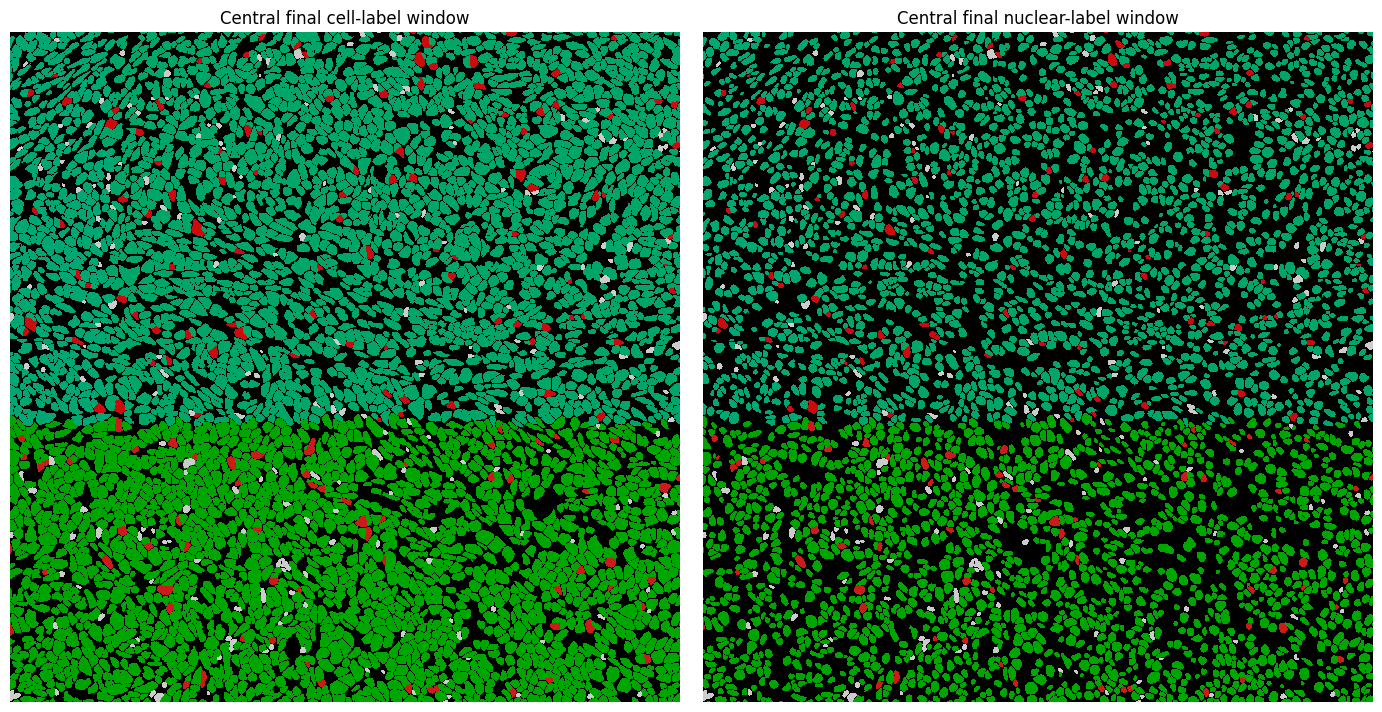

In [15]:
timing_report = pd.DataFrame(timing_log)
if not timing_report.empty:
    display(timing_report)

resource_report = pd.DataFrame(resource_log)
if not resource_report.empty:
    resource_report['elapsed_seconds'] = (
        resource_report['time'] - resource_report['time'].iloc[0]
    )
display(resource_report)

if WORK_STATE_JSON.exists():
    display(json.loads(WORK_STATE_JSON.read_text()))

# Show a few actual multi-nucleus parents before and after splitting.
for split_index, record in enumerate(globals().get('watershed_records', [])[:3], start=1):
    bbox = record['bbox']
    parent_id = record['parent_cell_id']
    raw_cell_crop = np.asarray(lazy_raw_cells[bbox])
    raw_nucleus_crop = np.asarray(lazy_raw_nuclei[bbox])
    final_cell_crop = np.asarray(final_cells[bbox])
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(raw_cell_crop == parent_id, cmap='gray', interpolation='nearest')
    axes[0].set_title(f'Raw parent cell {parent_id}')
    axes[1].imshow(raw_nucleus_crop, cmap='nipy_spectral', interpolation='nearest')
    axes[1].set_title(f"Markers: {record['nucleus_ids']}")
    axes[2].imshow(final_cell_crop, cmap='nipy_spectral', interpolation='nearest')
    axes[2].set_title(f"Daughters: {record['daughter_ids']}")
    for ax in axes:
        ax.axis('off')
    fig.suptitle(f'Watershed split example {split_index}')
    plt.tight_layout(); plt.show()

if (
    WORK_STATE_JSON.exists()
    and json.loads(WORK_STATE_JSON.read_text()).get('state') == 'final_reconciled'
):
    qc_size = 2048
    y0 = max(0, spatial_shape[0] // 2 - qc_size // 2)
    x0 = max(0, spatial_shape[1] // 2 - qc_size // 2)
    cell_qc = np.asarray(final_cells[y0:y0 + qc_size, x0:x0 + qc_size])
    nucleus_qc = np.asarray(final_nuclei[y0:y0 + qc_size, x0:x0 + qc_size])
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(cell_qc, cmap='nipy_spectral', interpolation='nearest')
    axes[0].set_title('Central final cell-label window')
    axes[1].imshow(nucleus_qc, cmap='nipy_spectral', interpolation='nearest')
    axes[1].set_title('Central final nuclear-label window')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## Notes

- The canonical mIF pipeline remains responsible for merged-image creation,
  channel selection, medium-mode InstanSeg behavior, and mask export conventions.
- Inference uses the patched projects/instanseg checkout with resolve_cell_and_nucleus=False.
- Source commit and settings are checked before any unresolved masks are reused.
- Watershed is local to ambiguous cell bounding boxes; global operations are
  chunked scans or disk-backed label lookup.
- Final nuclear and cell rasters share numeric instance IDs.
- This notebook writes experimental artifacts only and does not replace the
  production InstanSeg stage.
